In [ ]:
from google.colab import drive
drive.mount( '/content/gdrive' )

Mounted at /content/gdrive


In [ ]:
#Các hàm cần thiết để tính toán
import numpy as np
from numpy import pi
import matplotlib.pyplot as plt
import csv 
import math
import cv2

In [ ]:
e = math.e

def calT(x, y, z, lc, dc, delta, xx, zz):
  out = e ** (zz / delta) * (z - zz) * (1 / ((x - xx) ** 2 + (y + lc / 2 / dc * zz + lc / 2) ** 2 + (z - zz) ** 2) ** 1.5 - 1 / ((x - xx) ** 2 + (y - lc / 2 / dc * zz - lc / 2) ** 2 + (z - zz) ** 2) ** 1.5)
  return out


def calT_add3(x, y, z, wc, lc, dc, delta, yy, zz):
  out = (-2 * yy / lc) * e ** (zz / delta) * (z - zz) * (1 / ((x + wc / 2) ** 2 + (y - yy) ** 2 + (z - zz) ** 2) ** 1.5 + 1 / ((x - wc / 2) ** 2 + (y - yy) ** 2 + (z - zz) ** 2) ** 1.5)
  return out


def calT_add4(x, y, z, wc, lc, dc, delta, yy, zz):
  out = (2 * yy / lc) * e ** (zz / delta) * (z - zz) * (1 / ((x + wc / 2) ** 2 + (y - yy) ** 2 + (z - zz) ** 2) ** 1.5 + 1 / ((x - wc / 2) ** 2 + (y - yy) ** 2 + (z - zz) ** 2) ** 1.5)
  return out


def transform(x, y, x_offset, y_offset, angle):
  xr = (x - x_offset) * math.cos(angle * math.pi / 180) - (y - y_offset) * math.sin(angle * math.pi / 180)
  yr = (x - x_offset) * math.sin(angle * math.pi / 180) + (y - y_offset) * math.cos(angle * math.pi / 180)
  return xr, yr


def InteT(x, y, z, wc, lc, dc, delta):
  n = 20
  m = 20

  a = -wc / 2
  b = wc / 2
  c = -dc
  d = 0

  h = (d - c) / n
  k = (b - a) / m

  T2 = 0
  T3 = 0
  T4 = 0

  T1 = calT(x, y, z, lc, dc, delta, a, c) + calT(x, y, z, lc, dc, delta, b, c) + calT(x, y, z, lc, dc, delta, a, d) + calT(x, y, z, lc, dc, delta, b, d)

  for j in range(1, n):
    yj = c + j * h
    T3 = T3 + calT(x, y, z, lc, dc, delta, a, yj) + calT(x, y, z, lc, dc, delta, b, yj)

  for i in range(1, m):
    xi = a + i * k
    T2 = T2 + calT(x, y, z, lc, dc, delta, xi, c) + calT(x, y, z, lc, dc, delta, xi, d)
    for j in range(1, n):
      yj = c + j * h
      T4 = T4 + calT(x, y, z, lc, dc, delta, xi, yj)

  out = h * k * (T1 / 4 + T2 / 2 + T3 / 2 + T4)
  return out


def InteT_add3(x, y, z, wc, lc, dc, delta):
  n = 20
  m = 20

  x_ = np.zeros(m + 1)
  y_ = np.zeros((n + 1, m + 1))
  c = np.zeros(m + 1)
  d = np.zeros(m + 1)
  h = np.zeros(m + 1)

  sinalfa = dc / ((dc ** 2 + (lc / 2) ** 2) ** 0.5)

  a = -lc / 2
  b = 0

  k = (b - a) / m

  T2 = 0
  T3 = 0
  T4 = 0

  for j in range(m + 1):
    x_[j] = a + j * k
    c[j] = -x_[j] * 2 * dc / lc - dc
    d[j] = 0
    h[j] = (d[j] - c[j]) / n
    for i in range(n + 1):
      y_[i, j] = c[j] + i * h[j]

  T1 = h[0] * (calT_add3(x, y, z, wc, lc, dc, delta, x_[0], c[0]) + calT_add3(x, y, z, wc, lc, dc, delta, x_[0], d[0])) + h[m] * (calT_add3(x, y, z, wc, lc, dc, delta, x_[m], c[m]) + calT_add3(x, y, z, wc, lc, dc, delta, x_[m], d[m]))

  for i in range(n):
    T3 = T3 + h[0] * calT_add3(x, y, z, wc, lc, dc, delta, x_[0], y_[i, 0]) + h[m] * calT_add3(x, y, z, wc, lc, dc, delta, x_[m], y_[i, m])

  for j in range(m):
    T2 = T2 + (calT_add3(x, y, z, wc, lc, dc, delta, x_[j], c[j]) + calT_add3(x, y, z, wc, lc, dc, delta, x_[j], d[j])) * h[j]
    for i in range(n):
      T4 = T4 + (calT_add3(x, y, z, wc, lc, dc, delta, x_[j], y_[i, j])) * h[j]

  T1 = k * T1 / 4
  T2 = k * T2 / 2
  T3 = k * T3 / 2
  T4 = k * T4

  out = sinalfa * (T1 + T2 + T3 + T4)
  return out


def InteT_add4(x, y, z, wc, lc, dc, delta):
  n = 20
  m = 20

  x_ = np.zeros(m + 1)
  y_ = np.zeros((n + 1, m + 1))
  c = np.zeros(m + 1)
  d = np.zeros(m + 1)
  h = np.zeros(m + 1)

  a = 0
  b = lc / 2

  sinalfa = dc / ((dc ** 2 + (lc / 2) ** 2) ** 0.5)

  k = (b - a) / m

  T2 = 0
  T3 = 0
  T4 = 0

  for j in range(m + 1):
    x_[j] = a + j * k
    c[j] = x_[j] * 2 * dc / lc - dc
    d[j] = 0
    h[j] = (d[j] - c[j]) / n
    for i in range(n + 1):
      y_[i, j] = c[j] + i * h[j]

  T1 = h[0] * (calT_add4(x, y, z, wc, lc, dc, delta, x_[0], c[0]) + calT_add4(x, y, z, wc, lc, dc, delta, x_[0], d[0])) + h[m] * (calT_add4(x, y, z, wc, lc, dc, delta, x_[m], c[m]) + calT_add4(x, y, z, wc, lc, dc, delta, x_[m], d[m]))

  for i in range(n):
    T3 = T3 + h[0] * calT_add4(x, y, z, wc, lc, dc, delta, x_[0], y_[i, 0]) + h[m] * calT_add4(x, y, z, wc, lc, dc, delta, x_[m], y_[i, m])
  
  for j in range(m):
    T2 = T2 + (calT_add4(x, y, z, wc, lc, dc, delta, x_[j], c[j]) + calT_add4(x, y, z, wc, lc, dc, delta, x_[j], d[j])) * h[j]
    for i in range(n):
      T4 = T4 + (calT_add4(x, y, z, wc, lc, dc, delta, x_[j], y_[i, j])) * h[j]

  T1 = k * T1 / 4
  T2 = k * T2 / 2
  T3 = k * T3 / 2
  T4 = k * T4

  out = sinalfa * (T1 + T2 + T3 + T4)
  return out

In [ ]:
wc_all = np.linspace(0.3,1.5,12)
lc_all = np.linspace(2,20,19)
dc_all = np.linspace(0.1,3,29)

In [ ]:
import os
import csv
# path = "/content/gdrive/MyDrive/Dipole Model/Data/Low Data"
path1 = "/content/gdrive/MyDrive/Dipole Model/Data/Low Data"

In [ ]:
N = 16
Res = 0.78  # Resolution mm
aR = np.linspace(-N * Res, N * Res, 2 * N)
bR = np.linspace(-N * Res, N * Res, 2 * N)
H = np.zeros((len(aR), len(bR)))
x_offset=0
y_offset=0
angle=0
wc=0.7
lc=10
dc=3
z=1
freq=5000
sicma=35461000
mu=0.0000012566
csi=0.085
K=1.5
I=0.01
G=3981

delta = 1 / np.sqrt(pi * freq * mu * sicma) * 1000

for wc in wc_all:
  for lc in lc_all:
    for dc in dc_all:
      tam = 'Triangular' + '_' + str(wc) + '_' + str(lc) + '_' + str(dc) + '.csv'
      if(tam not in  os.listdir(os.path.expanduser(path1))):
        print(tam)
        H = np.zeros((len(aR), len(bR)))
        for u, xo in enumerate(aR):
          for v, yo in enumerate(aR):
            x, y = transform(xo, yo, x_offset, y_offset, angle)
            H[u, v] = InteT(x, y, z, wc, lc, dc, delta) + InteT_add3(x, y, z, wc, lc, dc, delta) - InteT_add4(x, y, z, wc, lc, dc, delta)
            H[u, v] = math.cos(angle * math.pi / 180) * H[u, v]

        H = csi/4/pi*H
        H = K*I*G*H
        name_params=['N','liff_off','Csi','K','I','f','sicma','mu','G','Res']
        params=[32, z, csi, K, I, freq, sicma, mu, G, Res]
        L = ['shape', 'width', 'length', 'depth','angle','x_offset','y_offset']
        C = ['Triangular', wc, lc, dc, angle, x_offset, y_offset]

        filename = '/content/gdrive/MyDrive/Dipole Model/Data/Low Data/' + C[0] + '_' + str(C[1]) + '_' + str(C[2]) + '_' + str(C[3]) + '.csv'

        with open(filename, 'w', newline='') as f:
          writer = csv.writer(f)
          writer.writerow(name_params)
          writer.writerow(params)
          writer.writerow(L)
          writer.writerow(C)
          writer.writerows(H)
          f.close()

Triangular_1.2818181818181817_16.0_2.482142857142857.csv
Triangular_1.2818181818181817_16.0_2.585714285714286.csv
Triangular_1.2818181818181817_16.0_2.689285714285714.csv
Triangular_1.2818181818181817_16.0_2.7928571428571427.csv
Triangular_1.2818181818181817_16.0_2.8964285714285714.csv
Triangular_1.2818181818181817_16.0_3.0.csv
Triangular_1.2818181818181817_17.0_0.1.csv
Triangular_1.2818181818181817_17.0_0.20357142857142857.csv
Triangular_1.2818181818181817_17.0_0.30714285714285716.csv
Triangular_1.2818181818181817_17.0_0.4107142857142857.csv
Triangular_1.2818181818181817_17.0_0.5142857142857142.csv
Triangular_1.2818181818181817_17.0_0.6178571428571428.csv
Triangular_1.2818181818181817_17.0_0.7214285714285714.csv
Triangular_1.2818181818181817_17.0_0.825.csv
Triangular_1.2818181818181817_17.0_0.9285714285714285.csv
Triangular_1.2818181818181817_17.0_1.032142857142857.csv
Triangular_1.2818181818181817_17.0_1.1357142857142857.csv
Triangular_1.2818181818181817_17.0_1.2392857142857143.csv
T

In [ ]:
N = 16
Res = 0.78  # Resolution mm
aR = np.linspace(-N * Res, N * Res, 2 * N)
bR = np.linspace(-N * Res, N * Res, 2 * N)
H = np.zeros((len(aR), len(bR)))
x_offset=0
y_offset=0
angle=90
wc=0.3
lc=3
dc=0.1
z=1
freq=10000
sicma=35461000
mu=0.0000012566
csi=0.085
K=1.5
I=0.01
G=3981

delta = 1 / np.sqrt(pi * freq * mu * sicma) * 1000

for u, xo in enumerate(aR):
  for v, yo in enumerate(aR):
    x, y = transform(xo, yo, x_offset, y_offset, angle)
    H[u, v] = InteT(x, y, z, wc, lc, dc, delta) + InteT_add3(x, y, z, wc, lc, dc, delta) - InteT_add4(x, y, z, wc, lc, dc, delta)
    H[u, v] = math.cos(angle * math.pi / 180) * H[u, v]

H = csi/4/pi*H
H = K*I*G*H

In [ ]:
H_tam=np.zeros((32,32))
dem=31
for i in range(32):
  H_tam[i]=H[dem]
  dem=dem-1
H_tam=H_tam.transpose()

In [ ]:
image = cv2.resize(H_tam, (int(H_tam.shape[0]/4), int(H_tam.shape[1]/4)), interpolation=cv2.INTER_CUBIC)

(-0.5, 6.5, -0.5, 7.5)

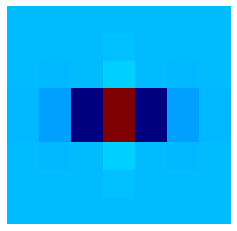

In [ ]:
fig=plt.figure(figsize=(4,4))
plt.subplot(1,1,1)
# plt.title('Image 08')
x_plot=np.diff(image)
plt.imshow(x_plot,vmin=x_plot.min(),vmax=x_plot.max(),origin="lower",interpolation=None,cmap=plt.cm.jet,aspect="auto")
plt.axis('off')

In [ ]:
fig.savefig('Image_Tria_0.3_3_0.1_None_Low_4.png', format='png')